## 4. Module 3 — Pattern / Text Mining

**Initial task description (Module 3 perspective):** 
Building upon our structural refinements in modules 1 and 2, our third analysis phase shifts focus from how we formally define "listening contexts" (clustering) to how we can exploit them (recommendations). In the previous phases, our evaluation pipeline measured cluster quality using Collaborative Filtering. Although a clear-cut solution, this method is notoriously susceptible to data sparsity [CITE], and estimates preferences based on general alignment, which could miss the strict thematic combinations that characterize music.

To address this limitation, we pivot to Pattern Mining. By applying frequent itemset mining and association rules internally within our established clusters, we can extract co-occurrence patterns that allow use to recommend tracks based on deterministic relationships rather than generalized user similarity. While pattern mining is generally even more vulnerable to sparsity than CF, executing it within our topologically dense clusters raises local support, allowing us to capture localized rules that would be invisible at a global scale. As pattern mining prioritizes precision over broad coverage, we integrate our original Collaborative Filtering model as a dynamic fallback mechanism. Ultimately, this approach investigates a core behavioural question: within a cohesive community, is human musical curation better predicted by exact programmatic track associations, or by generalized socio-musical alignment?


In [1]:
# prelims
import pandas as pd
from evaluation.evaluator import eval
from pattern_mining.rules.FPGrowGenerator import FPGrowthGenerator

In [2]:
# chore, load vars which we need for analysis
# load the dataframe 
from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
df = pd.read_parquet(FULLY_PROCESSED_PARQUET)
# load the tfidf matrix, unique texts and vectorizer for later use in part 2-3
from clustering.tf_idf_analysis.tf_idf_analysis import load_tfidf_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_cache_dir = "data/tfidf_cache"
tfidf_matrix, unique_texts, vectorizer = load_tfidf_matrix(tfidf_cache_dir, df, TfidfVectorizer)

[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...
[INFO] Loaded TF-IDF matrix shape: (84696, 5678)


In [3]:
# We would like to evaluate SVDKMeans  
svd_kmeans_cluster_col = "svd200_kmeans_55"
hybrid_output_dir = "evaluation/reports/Hybrid_FPGrowth_CF"

Saving evaluation results to: evaluation/reports/Hybrid_FPGrowth_CF/

CALCULATING SILHOUETTE SCORE

CALCULATING SILHOUETTE SCORE FOR svd200_kmeans_55
-> Final Silhouette Score (svd200_kmeans_55): 0.1148

Processing Cluster 32.0...
Number of samples in Cluster 32.0: 2849225
  -> Successfully split 11016 users into train/test sets.
  -> Sub-sampling to 200 users (out of 11016)...
  -> Mining association rules for cluster 32.0...
[FP-Growth | Cluster 32.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 32.0] Loaded 0 rules from cache in 0.00 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 12.0...
Number of samples in Cluster 12.0: 598278
  -> Successfully split 6266 users into train/test sets.
  -> Sub-sampling to 200 users (out of 6266)...
  -> Mining association rules for cluster 12.0...
[FP-Growth | Cluster 12.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 12.0] Loaded 0 rules from cache in 0.00 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 2.0...
Number of samples in Cluster 2.0: 181794
  -> Successfully split 3129 users into train/test sets.
  -> Sub-sampling to 200 users (out of 3129)...
  -> Mining association rules for cluster 2.0...
[FP-Growth | Cluster 2.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 2.0] Loaded 100 rules from cache in 0.00 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 4.0...
Number of samples in Cluster 4.0: 178788
  -> Successfully split 685 users into train/test sets.
  -> Sub-sampling to 200 users (out of 685)...
  -> Mining association rules for cluster 4.0...
[FP-Growth | Cluster 4.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 4.0] Loaded 941 rules from cache in 0.01 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 6.0...
Number of samples in Cluster 6.0: 166844
  -> Successfully split 1557 users into train/test sets.
  -> Sub-sampling to 200 users (out of 1557)...
  -> Mining association rules for cluster 6.0...
[FP-Growth | Cluster 6.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 6.0] Loaded 1719 rules from cache in 0.02 seconds.
  -> Generating recommendations & evaluating 200 sampled users...


...


Processing Cluster 50.0...
Number of samples in Cluster 50.0: 17307
  -> Successfully split 329 users into train/test sets.
  -> Sub-sampling to 200 users (out of 329)...
  -> Mining association rules for cluster 50.0...
[FP-Growth | Cluster 50.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 50.0] Loaded 1618 rules from cache in 0.02 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 51.0...
Number of samples in Cluster 51.0: 16048
  -> Successfully split 639 users into train/test sets.
  -> Sub-sampling to 200 users (out of 639)...
  -> Mining association rules for cluster 51.0...
[FP-Growth | Cluster 51.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 51.0] Loaded 5509 rules from cache in 0.05 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 48.0...
Number of samples in Cluster 48.0: 12156
  -> Successfully split 598 users into train/test sets.
  -> Sub-sampling to 200 users (out of 598)...
  -> Mining association rules for cluster 48.0...
[FP-Growth | Cluster 48.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 48.0] Loaded 2418 rules from cache in 0.02 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 35.0...
Number of samples in Cluster 35.0: 11732
  -> Successfully split 381 users into train/test sets.
  -> Sub-sampling to 200 users (out of 381)...
  -> Mining association rules for cluster 35.0...
[FP-Growth | Cluster 35.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 35.0] Loaded 74578 rules from cache in 0.76 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Saving metrics to evaluation/reports/Hybrid_FPGrowth_CF/evaluation_metrics_svd200_kmeans_55.txt...

Generating evaluation graphs...
Graph successfully saved as 'evaluation/reports/Hybrid_FPGrowth_CF/f01_comparison.png'


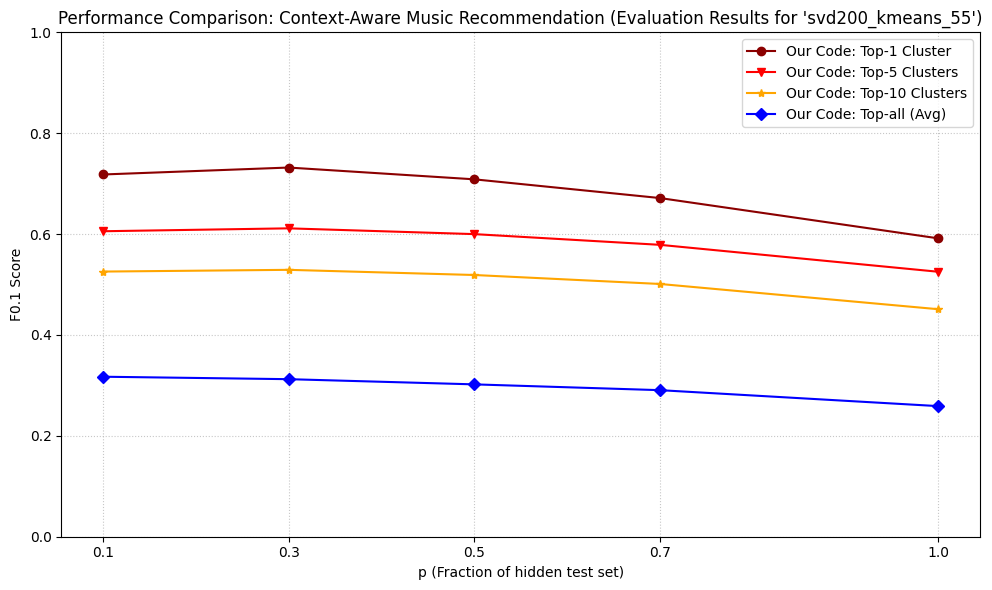


PLOTTING CLUSTER DISTRIBUTION
-> Distribution graph saved successfully to: evaluation/reports/Hybrid_FPGrowth_CF/cluster_distribution.png


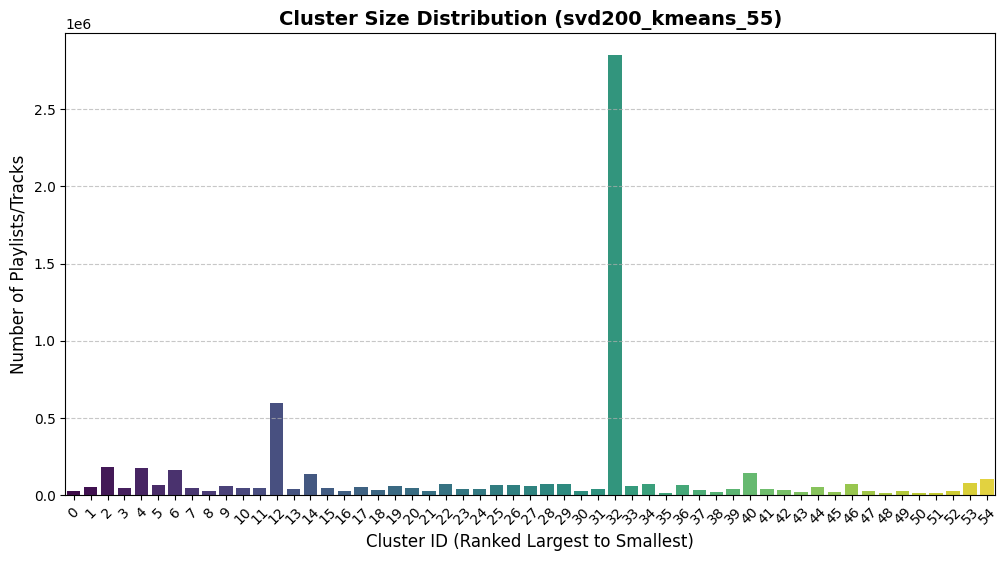


=== FINAL EVALUATION AVERAGES ===
Top-1 Average:   [np.float64(0.7182), np.float64(0.7319), np.float64(0.7086), np.float64(0.6715), np.float64(0.5916)]
Top-5 Average:   [np.float64(0.6056), np.float64(0.6114), np.float64(0.6), np.float64(0.5787), np.float64(0.5253)]
Top-all Average: [np.float64(0.3172), np.float64(0.3123), np.float64(0.3021), np.float64(0.2906), np.float64(0.2589)]


In [4]:
fp_generator = FPGrowthGenerator(
    min_support_pct=0.015, # rule must appear in at least x% of transactions (playlists) to be considered
    min_confidence=0.30, 
    config_name="hybrid_test_01"
)

# 2. Run the evaluation, passing the generator in
eval(
    df=df, 
    cluster_col=svd_kmeans_cluster_col, 
    unique_texts=unique_texts, 
    tfidf_matrix=tfidf_matrix, 
    output_dir=hybrid_output_dir,
    rule_generator=fp_generator # trigger rule mining and evaluation within the eval function
)